# RideWise · Notebook 07 — Threshold & Targeting

**Turn churn probabilities into an operating decision: who to contact, and which promotion to offer them.**

---

### What you will learn
- Why the default 0.5 threshold is rarely the right business choice
- How to flag the top-15% at-risk riders and read the precision/recall trade
- How to map at-risk riders to the promotions catalogue by segment and city
- How to estimate the business value of a retention campaign

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

The model gives every rider a probability. Operations needs an **action**:
a finite, ranked list of riders to contact this cycle, each matched to a
sensible offer. This notebook closes that gap.

In [1]:
# --- environment setup (run me first) ---
import sys, os
from pathlib import Path

# Make the shared pipeline importable whether you launch from notebooks/ or root
ROOT = Path.cwd()
if (ROOT / "src").exists():
    SRC = ROOT / "src"
elif (ROOT.parent / "src").exists():
    SRC = ROOT.parent / "src"
else:
    raise FileNotFoundError("Could not locate the src/ folder with ridewise_pipeline.py")
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("Setup OK · pipeline module at:", SRC)

Setup OK · pipeline module at: /home/claude/ridewise/src


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ridewise_pipeline import build_analytics_table, FEATURE_COLUMNS, RANDOM_STATE, load_raw
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
NAVY, ACCENT = "#1F3A5F", "#C8843C"

df = build_analytics_table()
X, y = df[FEATURE_COLUMNS].fillna(0), df["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=20,
                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr)
p = rf.predict_proba(X_te)[:, 1]
print("Scored", len(p), "held-out riders.")

Scored 2500 held-out riders.


## 2. The threshold is a business lever, not a default

Classifying at probability 0.5 is an arbitrary convention. The right cut-off
depends on **how many riders the retention team can contact** and the cost of a
false alarm versus a missed churner. Here we honour the project's brief: flag the
**top 15%** highest-risk riders.

In [3]:
thr = np.quantile(p, 0.85)  # top 15% by risk
flagged = (p >= thr).astype(int)
print(f"Operating threshold (top 15%): {thr:.3f}")
print(f"Riders flagged: {flagged.sum()} of {len(flagged)} ({flagged.mean():.1%})")
print(f"Precision at flag: {precision_score(y_te, flagged):.1%}  (share of flagged who truly churn)")
print(f"Recall at flag:    {recall_score(y_te, flagged):.1%}  (share of churners we caught)")

Operating threshold (top 15%): 0.674
Riders flagged: 375 of 2500 (15.0%)
Precision at flag: 68.5%  (share of flagged who truly churn)
Recall at flag:    35.6%  (share of churners we caught)


**Reading the trade-off.** Flagging only the top 15% gives high precision — most
flagged riders genuinely churn — so the retention budget is well spent, at the
cost of not catching every churner. The curve below lets the business pick a
different point if capacity changes.

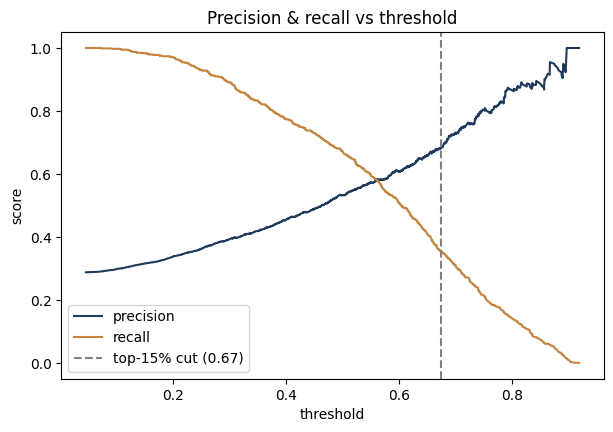

In [4]:
prec, rec, ths = precision_recall_curve(y_te, p)
plt.figure(figsize=(7, 4.5))
plt.plot(ths, prec[:-1], label="precision", color=NAVY)
plt.plot(ths, rec[:-1], label="recall", color=ACCENT)
plt.axvline(thr, ls="--", color="grey", label=f"top-15% cut ({thr:.2f})")
plt.xlabel("threshold"); plt.ylabel("score"); plt.title("Precision & recall vs threshold"); plt.legend(); plt.show()

## 3. Build the retention list

Rank flagged riders by risk, attach their segment and city, and hand operations
a clean table — the artefact that replaces weeks of manual analysis.

In [5]:
te_idx = X_te.index
retention = df.loc[te_idx, ["user_id", "city", "loyalty_status", "recency", "frequency", "monetary"]].copy()
retention["churn_risk"] = p
retention = retention[p >= thr].sort_values("churn_risk", ascending=False)
print("Retention list size:", len(retention))
retention.head(10)

Retention list size: 375


,user_id,city,loyalty_status,recency,frequency,monetary,churn_risk
9029,R09029,Cairo,Silver,56,9,134.62,0.918606
5316,R05316,Cairo,Bronze,98,9,138.53,0.907854
2978,R02978,Cairo,Silver,43,10,161.80,0.903918
2277,R02277,Cairo,Bronze,67,8,127.49,0.903899
9897,R09897,Lagos,Bronze,72,9,130.48,0.902513
9231,R09231,Cairo,Silver,160,11,175.49,0.901834
7224,R07224,Cairo,Bronze,90,9,139.76,0.900955
850,R00850,Cairo,Bronze,62,10,152.46,0.900419
2459,R02459,Lagos,Silver,46,9,166.43,0.897750
6782,R06782,Cairo,Bronze,75,9,147.05,0.897410


## 4. Match riders to promotions

The promotions catalogue defines offer types, target segments, city scope and
A/B groups. We map each at-risk rider to eligible promotions for their city.

In [6]:
promos = load_raw()["promotions"]
print("Promotion types available:", promos["promo_type"].unique().tolist())

def eligible_promos(city):
    mask = promos["city_scope"].isin([city, "All"])
    return promos.loc[mask, ["promo_id", "promo_name", "promo_type", "promo_value"]].head(3)

example_city = retention.iloc[0]["city"]
print(f"\nExample — offers for a high-risk rider in {example_city}:")
eligible_promos(example_city)

Promotion types available: ['surge_waiver', 'points', 'discount', 'credit']

Example — offers for a high-risk rider in Cairo:


,promo_id,promo_name,promo_type,promo_value
1,P001,Peak Hour Pass,surge_waiver,1.0
2,P002,Peak Hour Pass,surge_waiver,1.0
9,P009,Referral Special,credit,15.0


**A simple targeting rule.** High-value at-risk riders (top quartile of monetary)
warrant a `credit` or `discount` to protect lifetime value; lower-value at-risk
riders get cheaper `points` or `surge_waiver` nudges. This keeps spend
proportional to the value at stake.

In [7]:
hi_value_cut = retention["monetary"].quantile(0.75)
retention["offer_tier"] = np.where(retention["monetary"] >= hi_value_cut,
                                   "premium (credit/discount)", "nudge (points/surge waiver)")
retention["offer_tier"].value_counts()

offer_tier
nudge (points/surge waiver)    281
premium (credit/discount)       94
Name: count, dtype: int64

## 5. Estimate campaign value

A back-of-envelope business case: if we contact the flagged riders and a
plausible fraction respond, what revenue do we protect?

In [8]:
avg_monthly_value = retention["monetary"].mean() / 12   # rough monthly value per rider
true_churners_flagged = (y_te.loc[retention.index] == 1).sum()
assumed_save_rate = 0.30  # 30% of contacted true-churners retained (illustrative)
riders_saved = true_churners_flagged * assumed_save_rate
protected = riders_saved * avg_monthly_value * 6  # value over a 6-month horizon
print(f"True churners on the list:      {true_churners_flagged}")
print(f"Assumed save rate:              {assumed_save_rate:.0%}")
print(f"Riders retained (est.):         {riders_saved:.0f}")
print(f"Protected revenue (6 mo, est.): ${protected:,.0f}")
print("\n(Illustrative — replace assumptions with measured campaign results.)")

True churners on the list:      257
Assumed save rate:              30%
Riders retained (est.):         77
Protected revenue (6 mo, est.): $7,754

(Illustrative — replace assumptions with measured campaign results.)


## 6. Summary

- The threshold is treated as a business lever; we flag the top-15% at high precision.
- A ranked, deduplicated retention list replaces weeks of manual work.
- Riders are matched to promotions by city and value tier.
- A transparent value estimate frames the campaign business case.

**Next:** Notebook 08 serves the model and sets up monitoring.